## Exploration and comparison of tasseled cap components generated from different coefficients

This notebook compares Tasseled cap wetness, greeness and brightness (TCW, TCG and TCB) derived from different sets of coefficients to see if there are significant differences in the output data. 

### Why do this work?

We currently use a single set of coefficients for generating TCW, TCG and TCB across all of the Landsat sensors (5, 7, 8 and 9). We use the coefficients of [Crist (1985)](https://www.sciencedirect.com/science/article/abs/pii/0034425785901026?via%3Dihub) to calculate the TC components from the DEA Landsat surface reflectance data ([see here](https://link.springer.com/content/pdf/10.1007/s13157-023-01682-7.pdf) for explanation of how TCW is generated to be used in WIT).

However, there are sensor-specific coefficients published and widely used for each Landsat sensor, and the use of a single set of coefficients to generate TC's for all sensors may introduce errors into our final products. A comparison between the TC's being created using the currently implemented coefficients, and those recommended in the wider literature, should be done to determine if our TC product needs to be updated to include sensor-specific coefficients.

### What this notebook does

- Loads DEA Landsat ARD data
- Uses `dea_tools` `calculate_indices` to calculate TCW, TCG and TCB using the currently implemented coefficients, and also the Landsat 8/9 coefficients from [Baig et al. 2014](https://www.tandfonline.com/doi/citedby/10.1080/2150704X.2014.915434?scroll=top&needAccess=true)
- **ALso now the TCT coefficients in the IEEE conference paper by Bex, Dale and Robert**
- `dea_tools` `bandindices.py` has been modified to include versions of the TC equations using the Landsat 8 coefficients.
- Calculates the difference between each TC component generated using the two sets of coefficients
- Generates figures to illustrate the differences between the TC outputs of the differenc coefficients
- Calculates correlation for the pairs of coefficients
- Genrates the RMSE, MAE and bias between the coefficients for each TC

### Still in progress:
- import wofs and generate other spectral indicies and use this extra information to see if there are larger discrepencies between the TC coefficients for particular land covers (currently trying using FC)
- scale up the area of analysis to cover a wider area and variety of land covers. Potentially using the collect training data moduel from dea-tools (Africa) or selecting subsets from the golden tiles, or randomly selected pixels across the continent. Currently the notebook runs for a small area in Victoria, so the results should be seen as preliminary and for assessing the notebook itself, not the TC's.
- Add hypothesis testing (done)
- Investigate the broader literature on what degree of pre-rpocessing is ususally applied to the input data. Our ARD data has several quality checks/ processes applied to it. If it is different enough from what is published, and it would have a significant impact on the resulting coefficients, there would be an argument for DEA to generate our own coefficients that are tailored to our ARD data (To discuss with Bex)



In [327]:
%pip install ultraplot xskillscore pypalettes -q
#%pip install -U odc-stats -q


Note: you may need to restart the kernel to use updated packages.


## Setup

- Import packages
- start up dask
- initiate datacube
- establish base query (will be used for loading several datasets through the notebook)
- load data for landsat sensor

In [ ]:
import datacube
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import ultraplot as uplt
import xskillscore
import cartopy.crs as ccrs
from matplotlib.dates import MonthLocator, DateFormatter
from datacube.utils import masking
from scipy.stats import linregress
import calendar
import pypalettes
import warnings

from odc.algo._percentile import xr_quantile_bands

import sys

sys.path.insert(1, ".../Tools")
from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb, display_map
from dea_tools.dask import create_local_dask_cluster
from dea_tools.bandindices import calculate_indices

warnings.filterwarnings("ignore")


In [ ]:
create_local_dask_cluster()


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/40467/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/40467/status,Workers: 1
Total threads: 31,Total memory: 237.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34137,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/40467/status,Total threads: 31
Started: Just now,Total memory: 237.21 GiB
Comm: tcp://127.0.0.1:38331,Total threads: 31
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/39589/status,Memory: 237.21 GiB
Nanny: tcp://127.0.0.1:46609,


In [ ]:
dc = datacube.Datacube(app="TCP_initial_exploration")


In [ ]:
save_dir = "./dev/development_notebooks_JAG/01_projects/tassel_cap_exploration/"


In [ ]:
lat = -35.5200
lon = 144.0000
buffer = 0.05

lat_range = (lat - buffer, lat + buffer)
lon_range = (lon - buffer, lon + buffer)

resolution = (-30, 30)
measurements = [
    "nbart_blue",
    "nbart_green",
    "nbart_red",
    "nbart_nir",
    "nbart_swir_1",
    "nbart_swir_2",
    "oa_fmask",
    "oa_nbart_contiguity",
]


In [ ]:
# display_map(x=lon_range, y=lat_range)


In [ ]:
# set up baseline dc query. THis will be modified by functions as needed later on.
query = {
    "x": lon_range,
    "y": lat_range,
    "time": ("2024-01", "2024-12"),
    "resolution": resolution,
    "group_by": "solar_day",
    "output_crs": "EPSG:3577",
    "dask_chunks": {"time": 1, "x": 1024, "y": 1024},
}


### Load the Landsat ARD data 

We will use this to generate the TC's, rather than use the existing TC product. This way we know the same pre-processing has been applied to both sets of coefficients.

In [335]:
%%time

ds = load_ard(
    dc=dc,
    products=['ga_ls8c_ard_3', 'ga_ls9c_ard_3'],
    measurements = ["nbart_blue", "nbart_green", "nbart_red", "nbart_nir", "nbart_swir_1", "nbart_swir_2", "oa_fmask", "oa_nbart_contiguity"], #, "oa_fmask", "oa_nbart_contiguity"
    cloud_mask = 'fmask',
    mask_pixel_quality=True,
    mask_contiguity = True,
    **query
)


Finding datasets
    ga_ls8c_ard_3
    ga_ls9c_ard_3
Applying fmask pixel quality/cloud mask
Applying contiguity mask (oa_nbart_contiguity)
Returning 91 time steps as a dask array
CPU times: user 745 ms, sys: 244 ms, total: 989 ms
Wall time: 818 ms


In [ ]:
ds


<xarray.Dataset> Size: 316MB
Dimensions:              (time: 91, y: 398, x: 336)
Coordinates:
  * time                 (time) datetime64[ns] 728B 2024-01-01T00:09:22.12330...
  * y                    (y) float64 3kB -3.925e+06 -3.925e+06 ... -3.937e+06
  * x                    (x) float64 3kB 1.08e+06 1.08e+06 ... 1.09e+06 1.09e+06
    spatial_ref          int32 4B 3577
Data variables:
    nbart_blue           (time, y, x) float32 49MB dask.array<chunksize=(1, 398, 336), meta=np.ndarray>
    nbart_green          (time, y, x) float32 49MB dask.array<chunksize=(1, 398, 336), meta=np.ndarray>
    nbart_red            (time, y, x) float32 49MB dask.array<chunksize=(1, 398, 336), meta=np.ndarray>
    nbart_nir            (time, y, x) float32 49MB dask.array<chunksize=(1, 398, 336), meta=np.ndarray>
    nbart_swir_1         (time, y, x) float32 49MB dask.array<chunksize=(1, 398, 336), meta=np.ndarray>
    nbart_swir_2         (time, y, x) float32 49MB dask.array<chunksize=(1, 398, 336), meta=np.ndarray>
    oa_fmask             (time, y, x) uint8 12MB dask.array<chunksize=(1, 398, 336), meta=np.ndarray>
    oa_nbart_contiguity  (time, y, x) uint8 12MB dask.array<chunksize=(1, 398, 336), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

## Calculate TC's and metrics

- use `bandindices` to calculate the TC's using the existing coefficients (called `TCW`, `TCG` and `TCB` in this notebook) and the potential alternative coefficients ( named with the TC + sensor e.g. `TCW_ls8ls9`)
- get the difference between each TC pair
- Calculate RMSE, MAE and Bias from the difference

In [ ]:
"""
NOTE: for now, before running the index calculations, you need to go to the '...Tools' directory and run pip install to access local changes.
The bandindices.py file has had additional TC equations added to it in the branch. These are not part of the standard dea_tools package.
"""

ds_tc = calculate_indices(
    ds,
    index=[
        "TCW",
        "TCB",
        "TCG",
        "TCW_ls8",
        "TCB_ls8",
        "TCG_ls8",
        "TCW_DEA",
        "TCB_DEA",
        "TCG_DEA",
    ],
    drop=True,
    inplace=True,
    collection="ga_ls_3",
)


Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2', 'oa_fmask', 'oa_nbart_contiguity']


In [ ]:
"""
This list of variable pairs is used when we make graphs later on.
TODO: if notebook is extended to multi-year, may need to edit this.
"""

# variable_pairs = [
#     [("TCW", "TCW_ls8"), ("TCG", "TCG_ls8"), ("TCB", "TCB_ls8")],
#     [("TCW", "TCW_DEA"), ("TCG", "TCG_DEA"), ("TCB", "TCB_DEA")],
# ]

variable_pairs = {
    "baig_l8": [("TCW", "TCW_ls8"), ("TCG", "TCG_ls8"), ("TCB", "TCB_ls8")],
    "DEA_l8": [("TCW", "TCW_DEA"), ("TCG", "TCG_DEA"), ("TCB", "TCB_DEA")],
}


In [343]:
%%time

#make a new dataset to hold the metrics as they have different dims to the ds_tc (no x,y)
ds_metrics = xr.Dataset(coords={'time': ds_tc.coords['time']})
ds_metrics.attrs = ds_tc.attrs.copy()

for j, group in variable_pairs.items():
    print(group)
    for i, (var1, var2) in enumerate(group):
        diff = ds_tc[var1] - ds_tc[var2]
        ds_tc[f'{var2}_diff'] = diff

        ds_metrics[f'{var2}_RMSE'] = np.sqrt((diff ** 2).mean(dim=['x', 'y']))
        ds_metrics[f'{var2}_MAE'] = np.abs(diff).mean(dim=['x', 'y'])
        ds_metrics[f'{var2}_bias'] = diff.mean(dim=['x', 'y'])


[('TCW', 'TCW_ls8'), ('TCG', 'TCG_ls8'), ('TCB', 'TCB_ls8')]
[('TCW', 'TCW_DEA'), ('TCG', 'TCG_DEA'), ('TCB', 'TCB_DEA')]
CPU times: user 178 ms, sys: 2.05 ms, total: 181 ms
Wall time: 170 ms


In [345]:
%%time
#ds_metrics = ds_metrics.load()

ds_metrics.load()


Task exception was never retrieved
future: <Task finished name='Task-4665280' coro=<Client._gather.<locals>.wait() done, defined at /env/lib/python3.10/site-packages/distributed/client.py:2385> exception=AllExit()>
Traceback (most recent call last):
  File "/env/lib/python3.10/site-packages/distributed/client.py", line 2394, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-4665279' coro=<Client._gather.<locals>.wait() done, defined at /env/lib/python3.10/site-packages/distributed/client.py:2385> exception=AllExit()>
Traceback (most recent call last):
  File "/env/lib/python3.10/site-packages/distributed/client.py", line 2394, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-4665278' coro=<Client._gather.<locals>.wait() done, defined at /env/lib/python3.10/site-packages/distributed/client.py:2385> exception=AllExit()>
Traceback (most recen

CPU times: user 15.6 s, sys: 2.79 s, total: 18.4 s
Wall time: 52.5 s


<xarray.Dataset> Size: 7kB
Dimensions:       (time: 91)
Coordinates:
  * time          (time) datetime64[ns] 728B 2024-01-01T00:09:22.123303 ... 2...
    spatial_ref   int32 4B 3577
Data variables: (12/18)
    TCW_ls8_RMSE  (time) float32 364B 0.07508 0.06286 ... 0.07212 0.07683
    TCW_ls8_MAE   (time) float32 364B 0.07351 0.06051 ... 0.06959 0.07439
    TCW_ls8_bias  (time) float32 364B -0.07351 -0.06051 ... -0.06959 -0.07439
    TCG_ls8_RMSE  (time) float32 364B 0.01099 0.02372 ... 0.009574 0.01008
    TCG_ls8_MAE   (time) float32 364B 0.01071 0.02308 ... 0.009116 0.00962
    TCG_ls8_bias  (time) float32 364B 0.01071 0.02308 ... 0.009116 0.009619
    ...            ...
    TCG_DEA_RMSE  (time) float32 364B 0.04929 0.0136 0.04055 ... 0.05007 0.05327
    TCG_DEA_MAE   (time) float32 364B 0.0482 0.01102 0.03743 ... 0.04784 0.05129
    TCG_DEA_bias  (time) float32 364B 0.04817 0.003316 ... 0.04771 0.05121
    TCB_DEA_RMSE  (time) float32 364B 0.1258 0.03783 0.0835 ... 0.1198 0.1273
    TCB_DEA_MAE   (time) float32 364B 0.1178 0.03345 0.07473 ... 0.1116 0.119
    TCB_DEA_bias  (time) float32 364B -0.1178 -0.03341 ... -0.1116 -0.1189
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [ ]:
ds_metrics_month = ds_metrics.groupby("time.month")
ds_metrics_month_mean = ds_metrics_month.mean(dim="time")


In [ ]:
ds_month_test = np.array(
    [
        np.nanmedian(ds_tc["TCW"].groupby("time.month")[i].values.ravel())
        for i in np.arange(1, 13)
    ]
)
# ds_month_test_mean = ds_month_test.mean(dim="time")
ds_month_test


array([-0.1510634 , -0.17665775, -0.16780081, -0.1541299 , -0.10781384,
       -0.09034742, -0.08037432, -0.09892538, -0.11218216, -0.1521886 ,
       -0.19393228, -0.20872998], dtype=float32)

In [ ]:
ds_month_median = (
    ds_tc["TCW"]
    .chunk(dict(time=-1))
    .groupby("time.month")
    .quantile(0.5, dim=["time", "x", "y"])
)


In [ ]:
ds_month_dict = {
    q: ds_tc["TCW"]
    .chunk(dict(time=-1))
    .groupby("time.month")
    .quantile(q, dim=["time", "x", "y"])
    for q in [0.25, 0.5, 0.75]
}


In [ ]:
ds_tc["TCW"].groupby("time.month")[1]


<xarray.DataArray 'TCW' (time: 7, y: 398, x: 336)> Size: 4MB
dask.array<getitem, shape=(7, 398, 336), dtype=float32, chunksize=(1, 398, 336), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 56B 2024-01-01T00:09:22.123303 ... 202...
  * y            (y) float64 3kB -3.925e+06 -3.925e+06 ... -3.937e+06 -3.937e+06
  * x            (x) float64 3kB 1.08e+06 1.08e+06 ... 1.09e+06 1.09e+06
    spatial_ref  int32 4B 3577

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


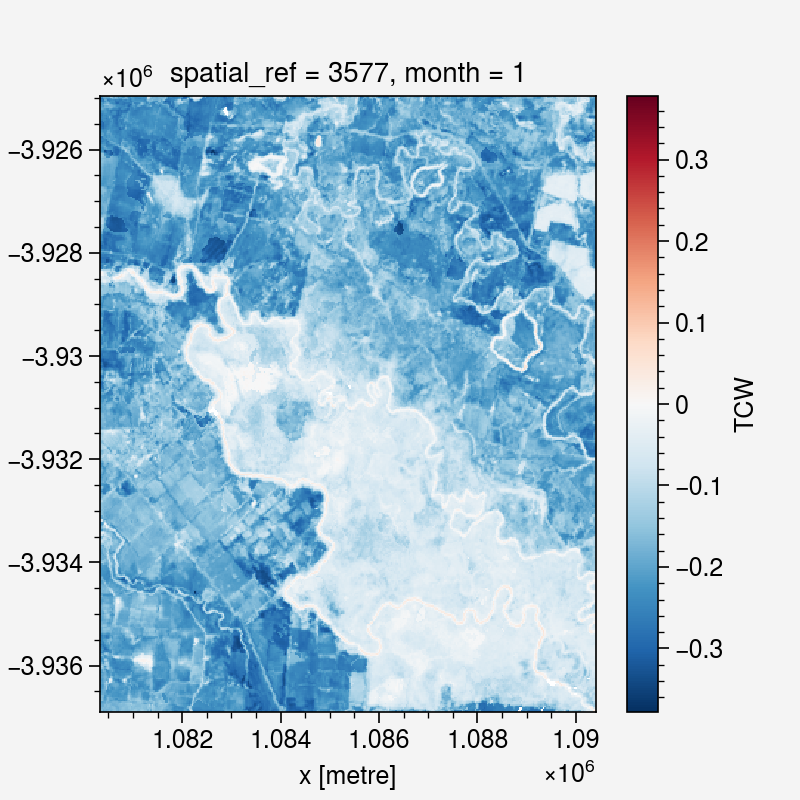

In [ ]:
ds_month_test_mean["TCW"][0].plot()


In [ ]:
f, ax = plt.subplots()
[ax.boxplot(ds_month_test[i]["TCW"], positions=[i]) for i in np.arange(1, 13)]
ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(calendar.month_abbr[1:13])
ax.set_ylabel("TCW")
ax.set_title("Monthly TCW")


In [ ]:
ds_tc["time"] = pd.to_datetime(ds_tc["time"].values)
monthly_groups = ds_tc.groupby("time.month")

# for month, group in monthly_groups:
#     print(f'month: {month}')
#     print(group)
#     print('\n')


### Generate masks for grouping data by broad land types

Using wofs and fractional cover, create mask arrays that will be applied to the TC's generated from the coefficients. 

This is to try and see if, in the result that there are differences between the TC coefficients, if those differences are related to particular land covers or conditions.

In [ ]:
"""
NOTE: this is a VERY rough proxy and should be replaced with a better set of thresholds to get actual groups of bare soil,
consistently vegetated areas (e.g native vegetation or forests) and dynamic agricultural regions.
"""

fc_mask = 40

ds_fc = dc.load(
    product="ga_ls_fc_pc_cyear_3",
    measurements=["pv_pc_50", "bs_pc_50", "npv_pc_50"],
    dask_chunks={"x": 1024, "y": 1024},
    **query
)

ds_fc = masking.mask_invalid_data(ds_fc)


In [ ]:
wofs_mask = 0.4  # set the threshold for classifying 'wet' pixels

ds_wofs = dc.load(
    product="ga_ls_wo_fq_cyear_3",
    measurements="frequency",
    dask_chunks={"x": 1024, "y": 1024},
    **query
)

ds_wof = masking.mask_invalid_data(ds_wofs)


In [ ]:
wofs_mask = (ds_wofs["frequency"] > wofs_mask).astype(int)

green_mask = (ds_fc["pv_pc_50"] > fc_mask) & (wofs_mask == 0).astype(int)
bare_mask = (ds_fc["bs_pc_50"] > fc_mask) & (wofs_mask == 0).astype(int)
non_green_mask = (ds_fc["npv_pc_50"] > fc_mask) & (wofs_mask == 0).astype(int)


The masks created earlier have a single timestep as they are created from annual products. 
They are broadcast across all of the timesteps for the xarray Dataset containing the TC's

Also, the dask chunks are different after boradcasting the time dimension, so rechunk to try and make the dataset more efficient

In [ ]:
# Step 3: Expand dims to match ds_tc time dimension
ds_tc["wofs_mask"] = wofs_mask.isel(time=0).expand_dims(time=ds_tc.time)
ds_tc["pv_fc_mask"] = green_mask.isel(time=0).expand_dims(time=ds_tc.time)
ds_tc["bs_fc_mask"] = bare_mask.isel(time=0).expand_dims(time=ds_tc.time)
ds_tc["npv_fc_mask"] = non_green_mask.isel(time=0).expand_dims(time=ds_tc.time)

chunks = {"time": 5}
ds_tc.chunk(chunks)


### Plot the differences between the TC's generated from the two sets of coefficients

- Create masks based on wofs (to see 'wet' pixels) and fractional cover (to see pixels that are likely to be green veg, non-green veg and bare earth)
- NOTE: These masks are rough approximations, and are here as a first pass/ proof of concept. The actual threshold values, or even the data source for making the masks, should be considered more carefully in the final report.


In [ ]:
all_values = xr.DataArray(
    data=np.ones_like(ds_tc["pv_fc_mask"], dtype=bool),
    coords=ds_tc["pv_fc_mask"].coords,
    dims=ds_tc["pv_fc_mask"].dims,
)

class_masks = {
    " ": all_values,
    "wofs_mask": ds_tc["wofs_mask"],
    f"fc pv > {fc_mask}%": ds_tc["pv_fc_mask"],
    f"bs pv > {fc_mask}%": ds_tc["bs_fc_mask"],
    f"npv pv > {fc_mask}%": ds_tc["npv_fc_mask"],
}


In [ ]:
%%time
ds_diff_ls8 = np.stack([ds_tc['TCW_ls8_diff'].values.flatten(), ds_tc['TCG_ls8_diff'].values.flatten(), ds_tc['TCB_ls8_diff'].values.flatten()], axis=1)
ds_diff_ls8.shape


In [ ]:
%%time
ds_diff_dea = np.stack([ds_tc['TCW_DEA_diff'].values.flatten(), ds_tc['TCG_DEA_diff'].values.flatten(), ds_tc['TCB_DEA_diff'].values.flatten()], axis=1)
ds_diff_dea.shape


## Generate plots

In [ ]:
%%time

fig, ax = uplt.subplots(refwidth=8, refaspect=(8,4))
ax.format(suptitle='Histogram of differences between the currently implemented coefficients (Crist 1985) and the Landsat-8 coefficients (Baig et al 2014) for TCW, TCG and TCB', xlabel='Difference', ylabel='Frequency')
res = ax.hist(
    ds_diff_ls8,
    bins=100,
    histtype='stepfilled',
    filled=True,
    alpha=0.6,
    edgecolor='k',
    cycle=('indigo4', 'green4', 'yellow4'),
    labels=list(['TCW', 'TCG', 'TCB']),
    legend='ul'
    
)
ax.format(xlim=(-0.3, 0.1))

fig.savefig(os.path.join(save_dir, "histogram_tc_diff_baig.png"), dpi=100, bbox_inches='tight')


In [ ]:

%%time

fig, ax = uplt.subplots(refwidth=8, refaspect=(8,4))
ax.format(suptitle='Histogram of differences between the currently implemented coefficients (Crist 1985) and the DEA IEEE paper coefficients for TCW, TCG and TCB', xlabel='Difference', ylabel='Frequency')
res = ax.hist(
    ds_diff_dea,
    bins=100,
    histtype='stepfilled',
    filled=True,
    alpha=0.6,
    edgecolor='k',
    cycle=('indigo4', 'green4', 'yellow4'),
    labels=list(['TCW', 'TCG', 'TCB']),
    legend='ul'
    
)
ax.format(xlim=(-0.3, 0.1))

fig.savefig(os.path.join(save_dir, "histogram_tc_diff_dea.png"), dpi=100, bbox_inches='tight')


In [ ]:
%%time

for j, group in variable_pairs.items():
    print(j)
    fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6,9), layout='constrained')
    for i, (var1, var2) in enumerate(group):
        ax=axs[i]

        rmse = ds_metrics[f'{var2}_RMSE'].values.flatten()
        mae = ds_metrics[f'{var2}_MAE'].values.flatten()
        bias = ds_metrics[f'{var2}_bias'].values.flatten()
        
        ax.scatter(ds_metrics['time'], rmse, label='RMSE',  marker='o', facecolors='none', edgecolors='SteelBlue')
        ax.scatter(ds_metrics['time'], mae, label='MAE',  marker='.', c='seagreen')
        ax.scatter(ds_metrics['time'], bias, label='bias',  marker='o', facecolors='none', edgecolors='darkorange')


        ax.set_title(f'{var1} vs {var2}')
        ax.set_xlabel('time')
        ax.set_ylabel('error')
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(DateFormatter('%b'))
        ax.xaxis.minorticks_off()
        ax.legend()

    fig.savefig(os.path.join(save_dir, f"{j}_tc_metrics.png"), dpi=100, bbox_inches='tight')
    plt.close(fig)


In [ ]:
%%time

for j, group in variable_pairs.items():
    fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6,9), layout='constrained')
    
    for i, (var1, var2) in enumerate(group):
        ax=axs[i]

        rmse = ds_metrics_month_mean[f'{var2}_RMSE']
        mae = ds_metrics_month_mean[f'{var2}_MAE']
        bias = ds_metrics_month_mean[f'{var2}_bias']
        
        ax.scatter(ds_metrics_month_mean['month'], rmse, label='RMSE',  marker='o', facecolors='none', edgecolors='SteelBlue')
        ax.scatter(ds_metrics_month_mean['month'], mae, label='MAE',  marker='.', c='seagreen')
        ax.scatter(ds_metrics_month_mean['month'], bias, label='bias',  marker='o', facecolors='none', edgecolors='darkorange')


        ax.set_title(f'{var1} vs {var2}')
        ax.set_xlabel('time')
        ax.set_ylabel('error')
        #ax.xaxis.set_major_locator(MonthLocator())
        #ax.xaxis.set_major_formatter(DateFormatter('%b'))
        ax.xaxis.minorticks_off()
        ax.legend()
    fig.savefig(os.path.join(save_dir, f"{j}_tc_metrics_monthly.png"), dpi=100, bbox_inches='tight')
    plt.close()


In [ ]:

%%time

for j, group in variable_pairs.items():
    fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10,10), layout='constrained')
    
    for i, (var1, var2) in enumerate(group):
        colors = ['darkblue', 'peachpuff']
        ax=axs[i]
        
        months = []
        positions = []
        data = []
        labels = []

        for month, group in monthly_groups:
            months.append(month)
            
            data1 = group[var1].values.ravel()
            data2 = group[var2].values.ravel()
            
            mask = ~np.isnan(data1) & ~np.isnan(data2)
            data1_clean = data1[mask]
            data2_clean = data2[mask]
            
            data.append(data1_clean)
            data.append(data2_clean)
            
            labels.append(f'{var1}')
            labels.append(f'{var2}')
            
            positions.append(month - 0.15)
            positions.append(month + 0.15)
            
        box_plot = ax.boxplot(data, positions=positions, widths=0.25, patch_artist=True, showfliers=False)
        
        for patch, color in zip(box_plot['boxes'], colors*12):
            patch.set_facecolor(color)

        ax.set_title(f'{var1} vs {var2}')
        ax.set_ylim(-0.6, 1)
        
        ax.set_ylabel('vals')
        ax.set_xlabel('Month')
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(DateFormatter('%b'))
        ax.xaxis.minorticks_off()
        
        legend_patches = [plt.Line2D([0], [0], color=colors[0], lw=4, label=var1), plt.Line2D([0], [0], color=colors[1], lw=4, label=var2)]
        ax.legend(handles=legend_patches, loc='upper right')
        ax.set_xlim(0.5, 12.5)
        #ax.tick_params(axis='x', rotation=70)

    fig.suptitle('Monthly boxplots for Tasseled cap variable pairs for Landsat 8', fontsize=14)

    fig.savefig(os.path.join(save_dir, f"{j}_tc_boxplots.png"), dpi=100, bbox_inches='tight')
    plt.close()


## things to do to improve code

 - [ ] calculate the RMSE, MAE etc before plotting!
 - [ ] rechunk?
 - [ ] compute the data before plotting vs computing the data while plotting
 - [ ] export csv of actual values to go into report

In [ ]:
%%time

colors = ('indigo4', 'green4', 'yellow4')

for j, group in variable_pairs.items():
    fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(15, 12), layout='constrained')
    
    for i, ((var1, var2), color) in enumerate(zip(group, colors)):
        ax=axs[i]

        data1 = ds_tc[var1].values.ravel()
        data2 = ds_tc[var2].values.ravel()
        mask = ~np.isnan(data1) & ~np.isnan(data2)
        data1_clean = data1[mask]
        data2_clean = data2[mask]
        
        lower_limit = np.min((data1_clean.min(), data2_clean.min())) - 0.05
        upper_limit = np.max((data1_clean.max(), data2_clean.max())) + 0.05

        for j, (class_name, class_mask) in enumerate(class_masks.items()):
            ax = axs[i,j]
            class_values = class_mask.values.ravel()[mask]

            hb = ax.hexbin(
                data1_clean[class_values==1],
                data2_clean[class_values==1],
                gridsize=100,
                cmap='viridis',
                mincnt=1
            )
            ax.set_xlim(lower_limit, upper_limit)
            ax.set_ylim(lower_limit, upper_limit)
            ax.plot((lower_limit, upper_limit), (lower_limit, upper_limit), c='darkgreen', alpha=0.5, ls='--', label='1:1')
            
            if np.sum(class_values ==1) >1:
                result = linregress(data1_clean[class_values==1], data2_clean[class_values==1])
            else:
                result = np.nan
            ax.plot(data1_clean[class_values==1], result.intercept + result.slope*data1_clean[class_values==1], c='darkorange', label='regression', alpha=0.75)
            ax.text(0.02, 0.98, f'p-val:{result.pvalue:.4f}', fontsize=12, ha='left', va='top', transform=ax.transAxes)

        # annotate
            ax.set_title(f'{var1} vs {var2}\n{class_name} R-sqr: {result.rvalue**2:.2f}')
            ax.set_xlabel(var1)
            ax.set_ylabel(var2)
            handles, labels = ax.get_legend_handles_labels()
            fig.legend(handles, labels, loc='upper left', ncol=1)


    fig.savefig(os.path.join(save_dir, f"{j}_tc_hexbin.png"), dpi=150, bbox_inches='tight')
    plt.close()


## Get TC percentiles and compare difference between variable pairs at 10, 50 and 90pc

- Use the `xr_quantile_bands` function to get the yearly 10th, 50th and 90th percentiles for the tasseled capped components generated with the current set of coefficients, and the proposed coefficients (drop unneeded data variables first)
- For each tasseled cap pair (TCW and TCW_new) and each percentile (10, 50, 90) calculate the delta and normalise the values between [-1, 1] so the difference between the tassel cap coefficients can be mapped
- threshold the delta values to see which areas are the most different between tassel caps derived from the different coefficients
- export summary `csv` of this to use in report

In [ ]:
def reduce(ds):
    yy = xr_quantile_bands(ds, [0.1, 0.5, 0.9], nodata=-9999)
    return yy


In [ ]:
ds_tc_percentiles_vars = ["TCW", "TCG", "TCB", "TCW_ls8ls9", "TCG_ls8ls9", "TCB_ls8ls9"]

ds_tc_prep = ds_tc.drop_vars(
    [var for var in ds_tc if var not in ds_tc_percentiles_vars + ["time", "x", "y"]]
)


In [ ]:
ds_tc_pc = reduce(ds_tc_prep)

ds_tc_pc


In [ ]:
percentiles = ["10", "50", "90"]

for i, (var1, var2) in enumerate(variable_pairs):
    for p in percentiles:
        var1_pc = f"{var1}_pc_{p}"
        var2_pc = f"{var2}_pc_{p}"

        if var1_pc in ds_tc_pc and var2_pc in ds_tc_pc:
            delta = ds_tc_pc[var1_pc] - ds_tc_pc[var2_pc]
            min_val = delta.min()
            max_val = delta.max()

            if max_val != min_val:
                normalised_delta = 2 * ((delta - min_val) / (max_val - min_val)) - 1
            else:
                normalised_delta = delta * 0

            ds_tc_pc[f"{var1_pc}_normalised_delta"] = normalised_delta
        else:
            print(f"Warning: {var1_pc} or {var2_pc} not found in dataset.")


In [ ]:
for i, (var1, var2) in enumerate(variable_pairs):
    for p in percentiles:
        var1_pc = f"{var1}_pc_{p}"
        var2_pc = f"{var2}_pc_{p}"

        if var1_pc in ds_tc_pc and var2_pc in ds_tc_pc:
            with np.errstate(divide="ignore", invalid="ignore"):
                percent_diff = (ds_tc_pc[var1_pc] - ds_tc_pc[var2_pc]) / ds_tc_pc[
                    var2_pc
                ]
                percent_diff = percent_diff.where(np.isfinite(percent_diff), 0)

                ds_tc_pc[f"{var1_pc}_percent_diff"] = percent_diff
        else:
            print(f"Warning: {var1_pc} or {var2_pc} not found in dataset.")


In [ ]:
ds_tc_pc.TCW_pc_50_percent_diff.plot(robust=True, cmap="RdBu_r")


In [ ]:
# apply threshold to TC delta

thresholds = (0.1, -0.1)

delta_threshold = ds_tc_pc.TCW_pc_50_normalised_delta.where(
    (ds_tc_pc.TCW_pc_50_normalised_delta > thresholds[0])
    | (ds_tc_pc.TCW_pc_50_normalised_delta < thresholds[1])
)

delta_threshold.plot(
    cmap="viridis",
    cbar_kwargs={"label": "TCW PC 50 Delta"},
)


In [ ]:
# data_vars = ["TCW_pc_10_delta", "TCG_pc_10_delta", "TCB_pc_10_delta"]

# fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), layout="constrained")

# for ax, var in zip(axes, data_vars):
#     ds_tc_pc[var].plot(ax=ax, cmap="viridis")
#     ax.set_title(var)
#     ax.set_xlabel("Longitude")
#     ax.set_ylabel("Latitude")
#     ax.set_aspect("auto")
